Using fonts from: /home/akhil/Invitation_research/static/fonts


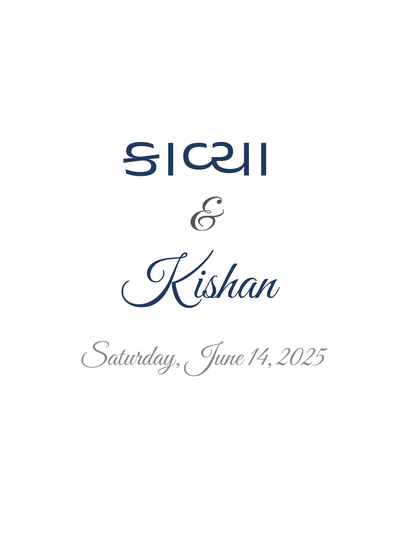

HQ base: 1584x2232  →  display preview: 396x558
Video saved: /home/akhil/Invitation_research/z_research/invitation_zoom_out.mp4
Frame size:  618x808


In [1]:
import os
import subprocess
from pathlib import Path

PROJECT_ROOT = Path('/home/akhil/Invitation_research')
FONT_DIR = PROJECT_ROOT / 'static' / 'fonts'
OUTPUT_DIR = PROJECT_ROOT / 'z_research'
FONTCONFIG_FILE = Path('/tmp/invitation-fontconfig.xml')
FONTCONFIG_CACHE = Path('/tmp/fontconfig-cache')
FONTCONFIG_CACHE.mkdir(exist_ok=True)

gujarati_font = FONT_DIR / 'AnekGujarati_Expanded-Regular.ttf'
english_font = FONT_DIR / 'GreatVibes-Regular.ttf'

fontconfig_xml = f"""<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>
  <include ignore_missing="yes">/etc/fonts/fonts.conf</include>
  <dir>{FONT_DIR}</dir>
  <cachedir>{FONTCONFIG_CACHE}</cachedir>
</fontconfig>
"""
FONTCONFIG_FILE.write_text(fontconfig_xml)
os.environ['FONTCONFIG_FILE'] = str(FONTCONFIG_FILE)

subprocess.run(
    ['fc-cache', '-f', str(FONT_DIR)],
    check=False,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

import cairo
import gi
from PIL import Image, ImageFont
from IPython.display import display

gi.require_version('Pango', '1.0')
gi.require_version('PangoCairo', '1.0')
from gi.repository import Pango, PangoCairo

print(f'Using fonts from: {FONT_DIR}')


def font_family(font_file: str | Path) -> str:
    """Return the internal family name Pango expects, e.g. 'Noto Sans Gujarati'."""
    return ImageFont.truetype(str(font_file), size=16).getname()[0]


def rgb(hex_color: str) -> tuple[float, float, float]:
    value = hex_color.lstrip('#')
    return tuple(int(value[i:i + 2], 16) / 255 for i in (0, 2, 4))


def pango_layout(ctx, text: str, family: str, size: int, max_width: int | None = None, align: str = 'left'):
    layout = PangoCairo.create_layout(ctx)
    layout.set_text(text, -1)

    desc = Pango.FontDescription()
    desc.set_family(family)
    desc.set_size(size * Pango.SCALE)
    layout.set_font_description(desc)

    if max_width:
        layout.set_width(max_width * Pango.SCALE)
        layout.set_wrap(Pango.WrapMode.WORD_CHAR)

    layout.set_alignment({
        'left': Pango.Alignment.LEFT,
        'center': Pango.Alignment.CENTER,
        'right': Pango.Alignment.RIGHT,
    }.get(align, Pango.Alignment.LEFT))
    layout.set_auto_dir(True)
    return layout


def render_text_layers_png(
    layers: list[dict],
    output: str | Path,
    canvas_size: tuple[int, int] = (800, 600),
    background: str | None = None,
):
    width, height = canvas_size
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, width, height)
    ctx = cairo.Context(surface)

    if background:
        ctx.set_source_rgb(*rgb(background))
        ctx.paint()
    else:
        ctx.set_source_rgba(0, 0, 0, 0)
        ctx.paint()

    for layer in layers:
        text = layer["text"]
        font_file = layer["font_file"]
        family = font_family(font_file)
        size = layer.get("size", 48)
        color = layer.get("color", "#111111")
        x = layer.get("x", 0)
        y = layer.get("y", 0)
        
        max_width = layer.get("max_width")
        align = layer.get("align", "left")

        layout = pango_layout(ctx, text, family, size, max_width, align)

        ctx.set_source_rgba(*rgb(color), 1)
        ctx.move_to(x, y)
        PangoCairo.show_layout(ctx, layout)

    output = Path(output)
    surface.write_to_png(str(output))
    return output


# ── Invitation config ──────────────────────────────────────────────────────────
# Edit layers here to change the invitation content. All coordinates are in
# display-resolution pixels (the canvas_size below).
invitation = {
    "canvas_size": (396, 558),
    "background": "#ffffff",
    "layers": [
        {
            "text": "કાવ્યા",
            "font_file": gujarati_font,
            "size": 42,
            "color": "#1f3a5f",
            "x": 120,
            "y": 120,
            "align": "left",
        },
        {
            "text": "&",
            "font_file": english_font,
            "size": 34,
            "color": "#555555",
            "x": 190,
            "y": 190,
        },
        {
            "text": "Kishan",
            "font_file": english_font,
            "size": 42,
            "color": "#1f3a5f",
            "x": 120,
            "y": 250,
        },
        {
            "text": "Saturday, June 14, 2025",
            "font_file": english_font,
            "size": 22,
            "color": "#888888",
            "x": 80,
            "y": 340,
            "align": "left",
        },
    ],
}

# ── Render HQ base image ───────────────────────────────────────────────────────
quality_scale = 4
canvas_w, canvas_h = invitation["canvas_size"]
hq_canvas = (canvas_w * quality_scale, canvas_h * quality_scale)

hq_layers = []
for layer in invitation["layers"]:
    hq_layer = {
        **layer,
        "x":    layer["x"]    * quality_scale,
        "y":    layer["y"]    * quality_scale,
        "size": layer["size"] * quality_scale,
    }
    if layer.get("max_width"):
        hq_layer["max_width"] = layer["max_width"] * quality_scale
    hq_layers.append(hq_layer)

hq_base_path = OUTPUT_DIR / "invitation_hq.png"
render_text_layers_png(
    hq_layers,
    hq_base_path,
    canvas_size=hq_canvas,
    background=invitation.get("background"),
)

preview = Image.open(hq_base_path).resize(invitation["canvas_size"], Image.Resampling.LANCZOS)
display(preview)
print(f"HQ base: {hq_canvas[0]}x{hq_canvas[1]}  →  display preview: {canvas_w}x{canvas_h}")

# ── Zoom-out animation ─────────────────────────────────────────────────────────
def hex_to_rgb8(hex_color: str) -> tuple[int, int, int]:
    value = hex_color.lstrip("#")
    return tuple(int(value[i:i + 2], 16) for i in (0, 2, 4))

video_bg = hex_to_rgb8(invitation.get("background", "#ffffff"))

base_rgba = Image.open(hq_base_path).convert("RGBA")
base_image = Image.new("RGBA", hq_canvas, (*video_bg, 255))
base_image.alpha_composite(base_rgba)

fps       = 60
duration  = 1
frames    = fps * duration

scale_start = 0.90
scale_end   = 0.55

padding_x, padding_y = 400, 500
final_w = round(canvas_w * scale_end)
final_h = round(canvas_h * scale_end)
video_w = final_w + padding_x
video_h = final_h + padding_y
video_w += video_w % 2
video_h += video_h % 2

render_w = video_w * quality_scale
render_h = video_h * quality_scale

video_path = OUTPUT_DIR / "invitation_zoom_out.mp4"

cmd = [
    "ffmpeg", "-y",
    "-framerate", str(fps),
    "-f", "image2pipe",
    "-vcodec", "png",
    "-i", "-",
    "-c:v", "libx264",
    "-crf", "14",
    "-preset", "slow",
    "-vf", "format=yuv420p",
    "-colorspace", "bt709",
    "-color_primaries", "bt709",
    "-color_trc", "bt709",
    "-movflags", "+faststart",
    str(video_path),
]

process = subprocess.Popen(cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)

for frame in range(frames):
    progress = frame / max(frames - 1, 1)
    t = 1 - (1 - progress) ** 3
    scale = scale_start + (scale_end - scale_start) * t

    disp_w = round(canvas_w * scale)
    disp_h = round(canvas_h * scale)
    img_w  = disp_w * quality_scale
    img_h  = disp_h * quality_scale

    scaled = base_image.resize((img_w, img_h), Image.Resampling.LANCZOS)

    canvas = Image.new("RGBA", (render_w, render_h), (*video_bg, 255))
    x = (render_w - img_w) // 2
    y = (render_h - img_h) // 2
    canvas.alpha_composite(scaled, (x, y))

    frame_img = canvas.resize((video_w, video_h), Image.Resampling.LANCZOS).convert("RGB")
    frame_img.save(process.stdin, format="PNG")


process.stdin.close()
stderr = process.stderr.read().decode()
if process.wait() != 0:
    print(stderr)
    raise RuntimeError("FFmpeg failed")

print(f"Video saved: {video_path}")
print(f"Frame size:  {video_w}x{video_h}")